# 01 Exploratory Data Analysis
**Project:** Behavioral Segmentation of Google Merchandise Store Users  
**Dataset:** `ga4_obfuscated_sample_ecommerce` · BigQuery Public Data  
**Period:** Nov 2020 – Jan 2021 · 92 days  
**Author:** Sebastian Weber · neuefische DA Bootcamp 2026

---

## Research Question
> Can k-means clustering on behavioral GA4 event data alone produce meaningful and defensible user segments, and where does the methodology reach its limits?

## Scope
This notebook covers:
- Data loading and validation
- Descriptive statistics
- Distribution analysis per feature
- Funnel analysis
- Outlier detection
- Correlation analysis
- Export of cleaned dataset for clustering

**All scope decisions (user filter, event selection, time range) are documented in `00_eda_scope_documentation.html`.**

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 2. Load Data

In [2]:
df = pd.read_csv('../data/raw/ga4_users_feature_engineered.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Shape: (270154, 8)

Columns: ['user_pseudo_id', 'session_count', 'is_new_user', 'page_views', 'items_viewed', 'add_to_cart', 'checkouts', 'purchases']


,user_pseudo_id,session_count,is_new_user,page_views,items_viewed,add_to_cart,checkouts,purchases
0,1041673.15,1,1,1,0,0,0,0
1,1051323.96,1,1,1,0,0,0,0
2,1132807.09,1,1,1,0,0,0,0
3,1147494.43,1,1,1,0,0,0,0
4,1148340.70,1,1,1,0,0,0,0


In [3]:
# Data types and nulls
print("Dtypes:")
print(df.dtypes)
print(f"\nNull values:")
print(df.isnull().sum())
print(f"\nDuplicates: {df.duplicated(subset='user_pseudo_id').sum()}")

Dtypes:
user_pseudo_id    float64
session_count       int64
is_new_user         int64
page_views          int64
items_viewed        int64
add_to_cart         int64
checkouts           int64
purchases           int64
dtype: object

Null values:
user_pseudo_id    0
session_count     0
is_new_user       0
page_views        0
items_viewed      0
add_to_cart       0
checkouts         0
purchases         0
dtype: int64

Duplicates: 0


## 3. Descriptive Statistics

In [4]:
features = ['session_count', 'is_new_user', 'page_views', 'items_viewed', 
            'add_to_cart', 'checkouts', 'purchases']

df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
session_count,270154.00,1.33,1.00,1.00,1.00,1.00,1.00,12.00
is_new_user,270154.00,0.95,0.21,0.00,1.00,1.00,1.00,1.00
page_views,270154.00,5.00,12.76,0.00,1.00,2.00,4.00,566.00
items_viewed,270154.00,1.43,6.44,0.00,0.00,0.00,0.00,330.00
add_to_cart,270154.00,0.22,1.80,0.00,0.00,0.00,0.00,98.00
checkouts,270154.00,0.14,1.12,0.00,0.00,0.00,0.00,66.00
purchases,270154.00,0.02,0.20,0.00,0.00,0.00,0.00,16.00


In [5]:
# Value counts for binary feature
print("is_new_user distribution:")
print(df['is_new_user'].value_counts())
print(f"\nNew user share: {df['is_new_user'].mean():.1%}")

is_new_user distribution:
is_new_user
1    257314
0     12840
Name: count, dtype: int64

New user share: 95.2%


In [6]:
# Conversion rate
converters = df[df['purchases'] > 0]
print(f"Users with at least one purchase: {len(converters):,} ({len(converters)/len(df):.2%})")
print(f"Total purchases across all users: {df['purchases'].sum():,}")

Users with at least one purchase: 4,419 (1.64%)
Total purchases across all users: 5,692


## 4. Distribution Analysis

Key question: are these features normally distributed, or heavily skewed? This matters for k-means, which is sensitive to scale and distribution shape.

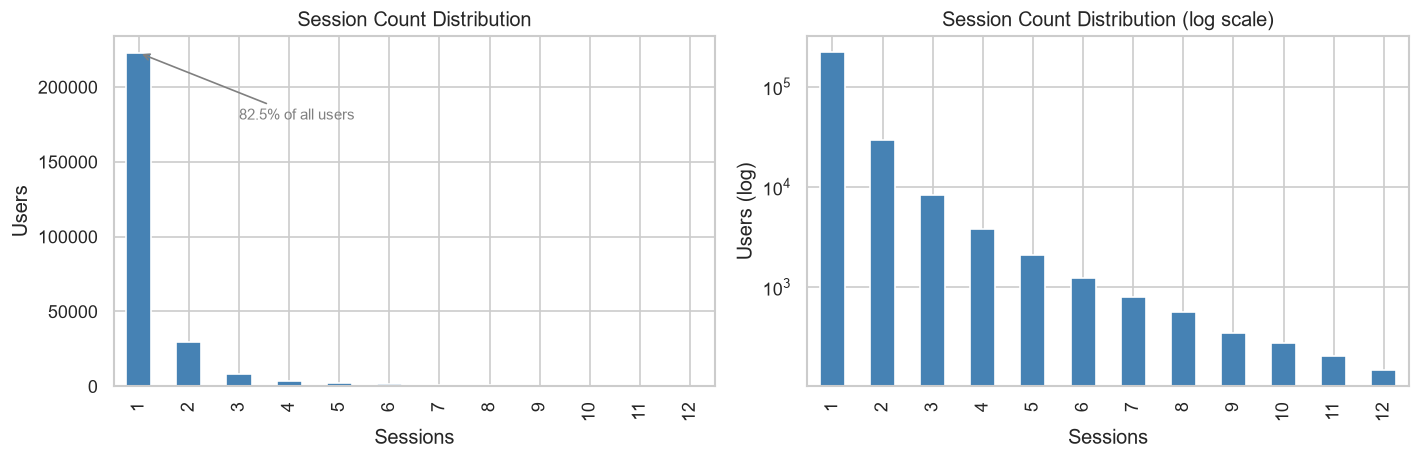


82.5% of all users have only 1 session.
This will dominate any clustering on raw data.


In [7]:
# Session count distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['session_count'].clip(upper=12).value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Session Count Distribution')
axes[0].set_xlabel('Sessions')
axes[0].set_ylabel('Users')

# Annotate the 1-session bar
single_session_pct = (df['session_count'] == 1).mean()
axes[0].annotate(
    f'{single_session_pct:.1%} of all users',
    xy=(0, df[df['session_count']==1].shape[0]),
    xytext=(2, df[df['session_count']==1].shape[0] * 0.8),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)

# Log scale version for readability
df['session_count'].clip(upper=12).value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_yscale('log')
axes[1].set_title('Session Count Distribution (log scale)')
axes[1].set_xlabel('Sessions')
axes[1].set_ylabel('Users (log)')

plt.tight_layout()
plt.savefig('../docs/01_session_distribution.png', bbox_inches='tight')
plt.show()

print(f"\n82.5% of all users have only 1 session.")
print(f"This will dominate any clustering on raw data.")

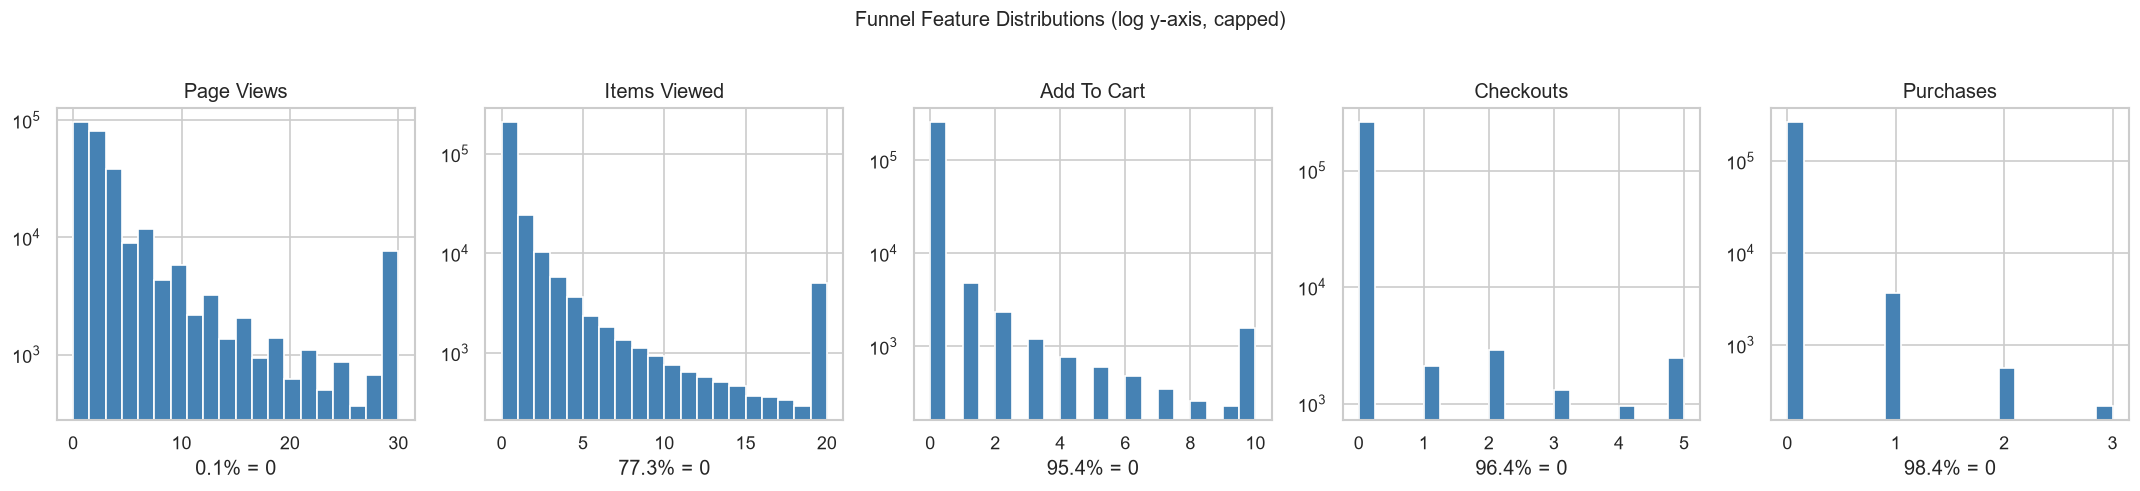

In [8]:
# Distribution of all funnel features
funnel_features = ['page_views', 'items_viewed', 'add_to_cart', 'checkouts', 'purchases']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

caps = {'page_views': 30, 'items_viewed': 20, 'add_to_cart': 10, 'checkouts': 5, 'purchases': 3}

for ax, feat in zip(axes, funnel_features):
    df[feat].clip(upper=caps[feat]).hist(bins=20, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_yscale('log')
    zero_pct = (df[feat] == 0).mean()
    ax.set_xlabel(f'{zero_pct:.1%} = 0')

plt.suptitle('Funnel Feature Distributions (log y-axis, capped)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('../docs/02_funnel_distributions.png', bbox_inches='tight')
plt.show()

## 5. Funnel Analysis

How many users reach each stage of the conversion funnel?

In [9]:
funnel = {
    'All Users':        len(df),
    'Viewed a Page':    (df['page_views'] > 0).sum(),
    'Viewed an Item':   (df['items_viewed'] > 0).sum(),
    'Added to Cart':    (df['add_to_cart'] > 0).sum(),
    'Started Checkout': (df['checkouts'] > 0).sum(),
    'Purchased':        (df['purchases'] > 0).sum(),
}

funnel_df = pd.DataFrame(funnel.items(), columns=['Stage', 'Users'])
funnel_df['Share of Total'] = (funnel_df['Users'] / len(df) * 100).round(2)
funnel_df['Drop-off vs Previous'] = funnel_df['Users'].pct_change().mul(100).round(1)

print(funnel_df.to_string(index=False))

           Stage  Users  Share of Total  Drop-off vs Previous
       All Users 270154          100.00                   NaN
   Viewed a Page 269792           99.87                 -0.10
  Viewed an Item  61252           22.67                -77.30
   Added to Cart  12545            4.64                -79.50
Started Checkout   9715            3.60                -22.60
       Purchased   4419            1.64                -54.50


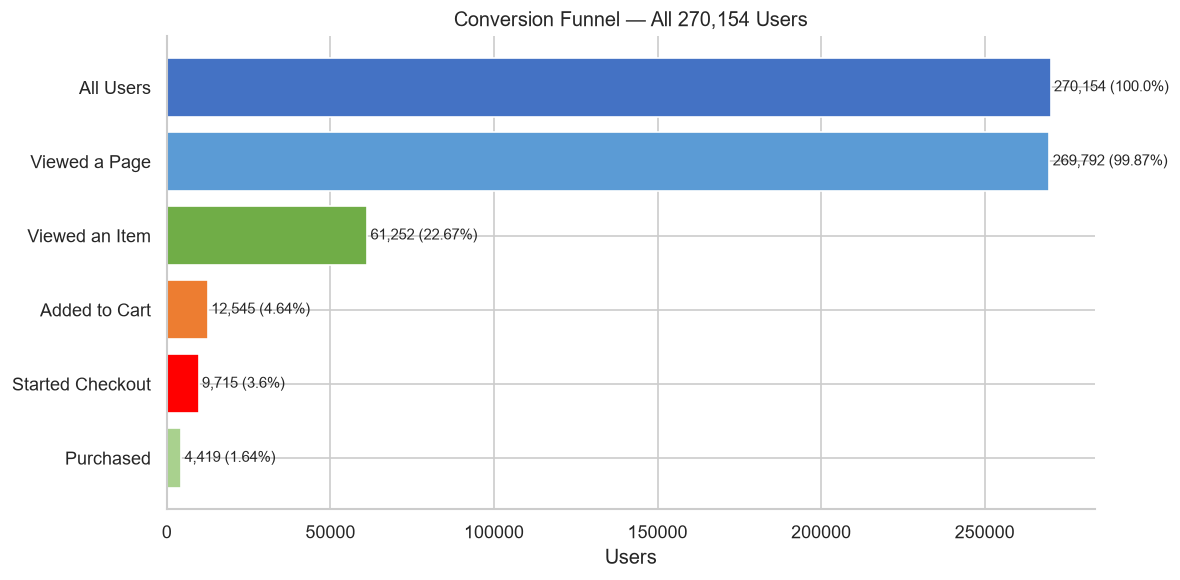

In [10]:
# Funnel chart
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#4472C4', '#5B9BD5', '#70AD47', '#FFC000', '#FF0000']
bars = ax.barh(
    funnel_df['Stage'][::-1],
    funnel_df['Users'][::-1],
    color=['#4472C4', '#5B9BD5', '#70AD47', '#ED7D31', '#FF0000', '#A9D18E'][::-1],
    edgecolor='white'
)

for bar, (_, row) in zip(bars, funnel_df[::-1].iterrows()):
    ax.text(
        bar.get_width() + 1000, bar.get_y() + bar.get_height() / 2,
        f"{row['Users']:,} ({row['Share of Total']}%)",
        va='center', fontsize=9
    )

ax.set_xlabel('Users')
ax.set_title('Conversion Funnel — All 270,154 Users')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../docs/03_funnel.png', bbox_inches='tight')
plt.show()

## 6. Outlier Detection

k-means is sensitive to outliers. We need to understand the upper tail of each feature before clustering.

In [11]:
# 99th percentile per feature
clustering_features = ['session_count', 'page_views', 'items_viewed', 
                        'add_to_cart', 'checkouts', 'purchases']

percentiles = df[clustering_features].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 1.0])
print("Percentiles per feature:")
percentiles

Percentiles per feature:


,session_count,page_views,items_viewed,add_to_cart,checkouts,purchases
0.50,1.00,2.00,0.00,0.00,0.00,0.00
0.75,1.00,4.00,0.00,0.00,0.00,0.00
0.90,2.00,9.00,2.00,0.00,0.00,0.00
0.95,3.00,17.00,6.00,0.00,0.00,0.00
0.99,6.00,66.00,33.00,6.00,4.00,1.00
1.00,12.00,566.00,330.00,98.00,66.00,16.00


C:\Users\s-web\AppData\Local\Temp\ipykernel_2260\3270750675.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[feat], vert=True, patch_artist=True,
C:\Users\s-web\AppData\Local\Temp\ipykernel_2260\3270750675.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[feat], vert=True, patch_artist=True,
C:\Users\s-web\AppData\Local\Temp\ipykernel_2260\3270750675.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[feat], vert=True, patch_artist=True,
C:\Users\s-web\AppData\Local\Temp\ipykernel_2260\3270750675.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Us

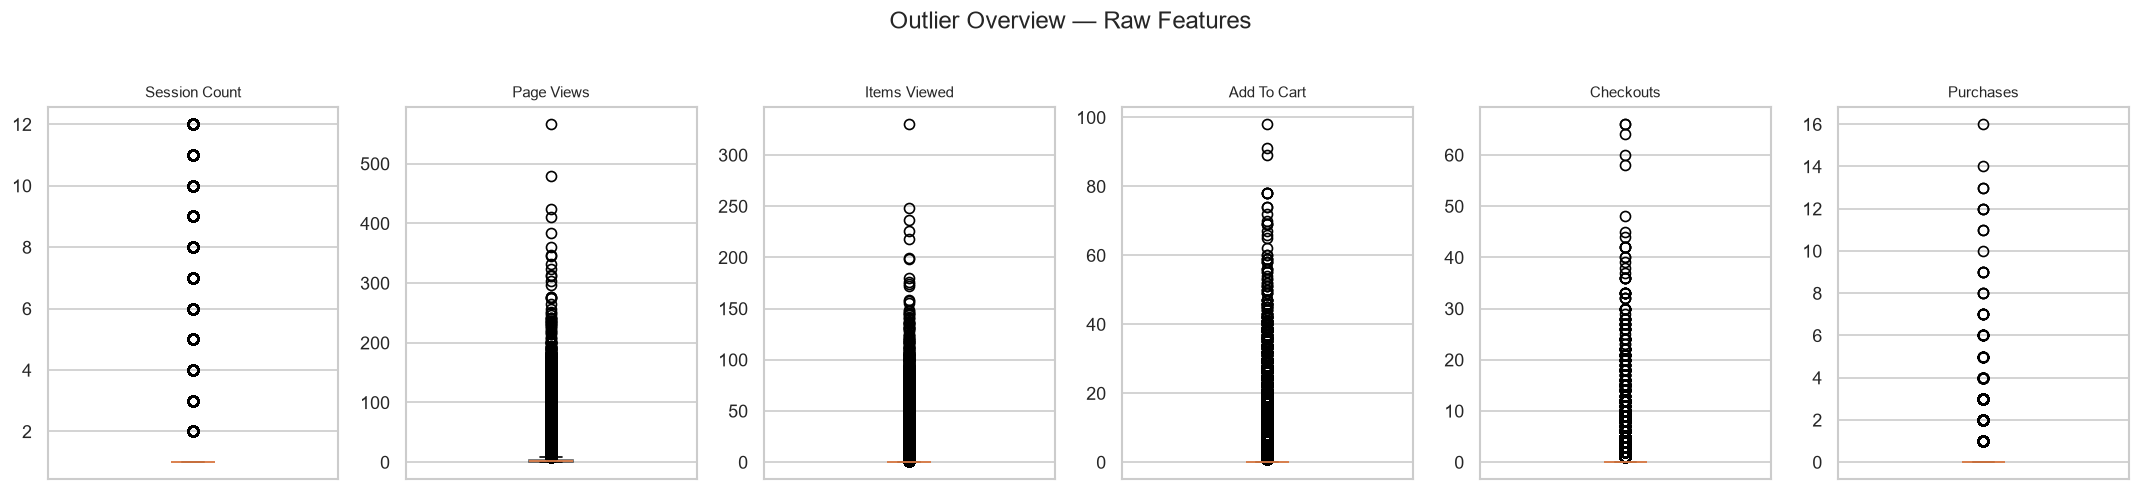


Note: Heavy right skew is expected. Log-transform will be applied before clustering.


In [12]:
# Boxplots to visualize outliers
fig, axes = plt.subplots(1, len(clustering_features), figsize=(18, 4))

for ax, feat in zip(axes, clustering_features):
    ax.boxplot(df[feat], vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(feat.replace('_', ' ').title(), fontsize=9)
    ax.set_xticks([])

plt.suptitle('Outlier Overview — Raw Features', y=1.02)
plt.tight_layout()
plt.savefig('../docs/04_outliers.png', bbox_inches='tight')
plt.show()

print("\nNote: Heavy right skew is expected. Log-transform will be applied before clustering.")

## 7. Correlation Analysis

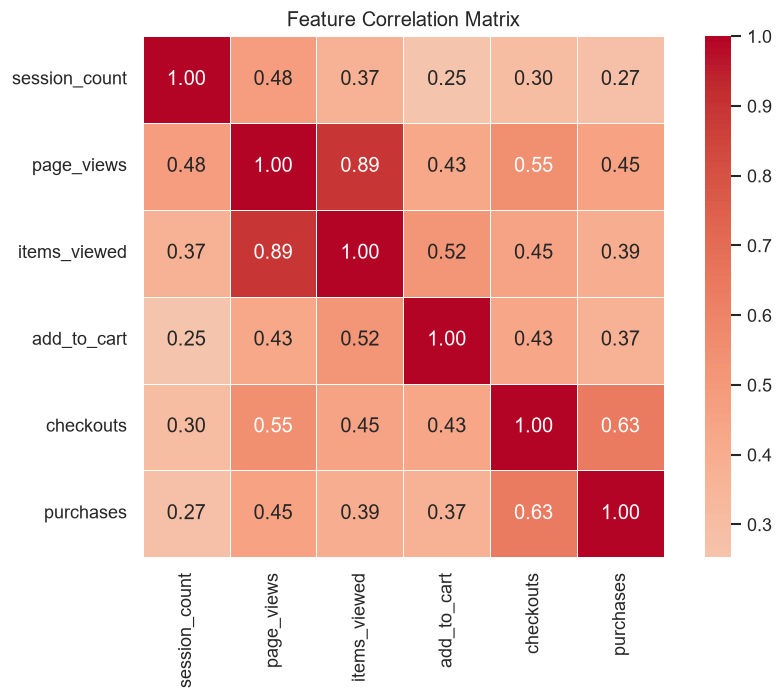

In [13]:
corr = df[clustering_features].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, ax=ax,
    linewidths=0.5
)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../docs/05_correlation.png', bbox_inches='tight')
plt.show()

## 8. Key Findings

Document your findings here before moving to clustering.

In [14]:
print("=== EDA KEY FINDINGS ===")
print()
print(f"Total users:            {len(df):,}")
print(f"Single-session users:   {(df['session_count']==1).sum():,} ({(df['session_count']==1).mean():.1%})")
print(f"New users:              {df['is_new_user'].sum():,} ({df['is_new_user'].mean():.1%})")
print()
print(f"Users who viewed item:  {(df['items_viewed']>0).sum():,} ({(df['items_viewed']>0).mean():.1%})")
print(f"Users who added to cart:{(df['add_to_cart']>0).sum():,} ({(df['add_to_cart']>0).mean():.1%})")
print(f"Users who purchased:    {(df['purchases']>0).sum():,} ({(df['purchases']>0).mean():.2%})")
print()
print("METHODOLOGICAL NOTE:")
print("82.5% single-session users will dominate k-means clustering.")
print("This is not a data quality problem. It is the central empirical")
print("finding that motivates the research question.")
print("See: Dolnicar & Grun (2008), Challenging Future Cluster Analysis.")

=== EDA KEY FINDINGS ===

Total users:            270,154
Single-session users:   222,790 (82.5%)
New users:              257,314 (95.2%)

Users who viewed item:  61,252 (22.7%)
Users who added to cart:12,545 (4.6%)
Users who purchased:    4,419 (1.64%)

METHODOLOGICAL NOTE:
82.5% single-session users will dominate k-means clustering.
This is not a data quality problem. It is the central empirical
finding that motivates the research question.
See: Dolnicar & Grun (2008), Challenging Future Cluster Analysis.


## 9. Export Cleaned Dataset

In [15]:
# No rows dropped — all 270,154 users are valid.
# user_pseudo_id kept as index reference but excluded from clustering features.

df.to_csv('../data/processed/ga4_users_clean.csv', index=False)
print(f"Saved: ../data/processed/ga4_users_clean.csv")
print(f"Shape: {df.shape}")
print(f"\nReady for 02_clustering.ipynb")

Saved: ../data/processed/ga4_users_clean.csv
Shape: (270154, 8)

Ready for 02_clustering.ipynb
